# Credit Card Fraud Detection — Executive Overview
**Prepared for:** Senior Management & Non-Technical Stakeholders  
**Purpose:** Proof-of-Concept Model Evaluation  
**Prepared by:** Wei Zhang - UBC Dentistry   

**GitHub Repository Forked:** https://github.com/procome/azureml-example


---

Financial fraud remains one of the most costly operational risks in the financial services sector. This notebook demonstrates a **proof‑of‑concept fraud detection system** built using Azure Machine Learning. It walks through the full lifecycle of a modern ML solution—from loading data to training a model, evaluating its performance, and preparing it for deployment.

This notebook explains **how the fraud detection pipeline works**, why each step matters, and how the results support informed decision‑making by business leaders.

This proof‑of‑concept uses a well‑known public dataset of credit card transactions to simulate how our organization could detect suspicious activity in real time. The model used here—**Isolation Forest**—is a widely adopted anomaly‑detection technique that identifies unusual patterns without requiring large volumes of labelled fraud examples.

---
## Summary of the Complete Process

The diagram below shows the end-to-end pipeline — from raw transaction data to a deployed, registered fraud-detection model:
```
┌──────────────────────────────────────────────────────────────┐   
│                    Fraud Detection Pipeline                  │   
└──────────────────────────────────────────────────────────────┘   
                              ▼
┌──────────────────────────────┐
│ 1. Data Load                 │  Load registered dataset from
└──────────────────────────────┘  Azure ML
                              ▼
┌──────────────────────────────┐
│ 2. Prep Data                 │  Clean, scale, and structure
└──────────────────────────────┘  features
                              ▼
┌──────────────────────────────┐
│ 3. Train Model               │  Isolation Forest learns normal
└──────────────────────────────┘  vs. unusual patterns
                              ▼
┌──────────────────────────────┐
│ 4. Evaluate Results          │  Precision, recall, and 
└──────────────────────────────┘  fraud‑detection performance
                              ▼
┌──────────────────────────────┐
│ 5. Register Model            │  Store versioned model in Azure
└──────────────────────────────┘  for deployment
                              ▼
┌──────────────────────────────┐
│ 6. Visualize Predictions     │  Summary of anomalies flagged
└──────────────────────────────┘
```


---

## Azure ML Components Used in This Project

| Azure ML Component | Role in This Project |
|---|---|
| **Azure ML Workspace** | The central hub where all project assets (data, models, experiments) are stored and managed. Think of it as the 'project folder' in the cloud. |
| **Azure ML Datasets** | Stores the credit card transaction data securely in the cloud, making it accessible to any team member without emailing files around. |
| **Azure ML Model Registry** | After training, the finished model is saved here. This allows the model to be versioned, audited, and deployed to production later. |
| **Jupyter Notebook (Authoring)** | The interactive document you are reading now. It combines code, results, and explanations in one place, ideal for communicating findings to stakeholders. |
| **Azure Compute** | Cloud-based computing power that runs the analysis. Allows us to process large datasets without needing expensive local hardware. |

---


### Step 1 — Setting Up the Required Tools

This section loads the software libraries needed to run the fraud detection workflow. These libraries allow us to:
- Connect securely to Azure ML
- Load the registered dataset
- Train the anomaly‑detection model
- Evaluate performance
- Save the model for future deployment

No business data is modified at this stage—this is simply preparing the environment

In [1]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # see https://pypi.org/project/azureml-core/
import pandas as pd                                 # see https://pandas.pydata.org/docs/
from sklearn.ensemble import IsolationForest        # see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
from sklearn.metrics import classification_report   # see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
from azureml.core.model import Model                # see https://docs.microsoft.com/en-us/python/api/azureml-core/azureml.core.model?view=azure-ml-py 

### Step 2 — Loading the Credit Card Transaction Data from Azure

Here we retrieve the dataset that was previously uploaded into Azure ML. Storing data in Azure ML ensures:

• 	**Governance**: version control and auditability   
• 	**Security**: data never leaves the cloud environment   
• 	**Reproducibility**: every run uses the same trusted dataset   

The output preview confirms that the data has loaded correctly.


In [ ]:
# You only need to run this if you've imported this notebook to Azure AI Machine Learning Studio - Notebook,
# in which case you'll also need to upload the config.json file to the same directory as this notebook,
# and then execute this code to determine the current working directory.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())



In [3]:

# if you're running locally then use this ...
path = None

# alternatively, if you're running in Azure AI Machine Learning Studio - Notebook, then use this ...
# (make sure to upload the config.json file to the same directory as this notebook)
#  and then execute this code to determine the current working directory.
path='.azureml/config.json'
ws = Workspace.from_config(path=path)
dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
df = dataset.to_pandas_dataframe()
df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Step 3 — Preparing the Data for Analysis

Before training the model, we **standardize** the transaction amount and remove fields that do not meaningfully contribute to fraud detection.

Why this matters:
- Fraud detection models perform best when all features are on comparable scales.
- Cleaning and structuring data reduces noise and improves accuracy.
- This step mirrors the data‑quality checks required in a production environment.


In [4]:
df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

### Step 4 — Training the AI Fraud Detection Model

We use **Isolation Forest**, an industry‑standard anomaly detection algorithm.

Why this model:   
• 	It does not require large volumes of labelled fraud cases.   
• 	It identifies unusual patterns by isolating outliers.   
• 	It is fast, scalable, and well‑suited for financial transaction streams.  

The model learns what “normal” behaviour looks like and flags transactions that deviate significantly.

**Business implication:** This model could operate on live transaction streams without needing a human to label fraud examples first — a significant operational advantage.

In [5]:
model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

### Step 5: Evaluating the Anomaly Detection Model


#### Results Summary

| Class | Description           | Precision | Recall | F1-Score | Support |
|-------|------------------------|-----------|--------|----------|---------|
| `0`   | Normal transactions    | **1.00**  | **1.00** | **1.00**   | 284,315 |
| `1`   | Fraudulent transactions| **0.29**  | **0.28** | **0.28**   | 492     |

#### Interpretation 

- The model is **excellent at recognizing normal transactions** — it almost never makes a mistake with those.
- However, it **struggles to correctly catch fraud**:
  - When it says a transaction is fraud, it’s **only right 29% of the time**.
  - It **only finds 28% of the real fraud cases** — it misses most of them.

#### Overall Accuracy

- The model is **99.9% accurate**, but this is misleading.
- Because **fraud cases are very rare**, the model can look “perfect” just by saying everything is normal.
- We need to look at **precision**, **recall**, and **F1-score** for a fuller picture.

In practical business terms, this means **the model generates many false alarms while still missing most fraudulent activity**. For every four transactions it flags, three are legitimate customers who may experience unnecessary friction. At the same time, three out of four real fraud cases slip through undetected, which represents direct financial loss and potential regulatory exposure.


In [6]:
# Step 5: Evaluate Model
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



### Step 6 — Saving the Model for Future Use

Registering the model in Azure ML:  
- Creates a versioned, auditable record  
- Enables deployment to production systems   
- Ensures governance and traceability for compliance teams   

This is the ML equivalent of publishing a software release.

In [7]:
import joblib                                       # see https://joblib.readthedocs.io/en/latest/
                                                    #     Joblib is a set of tools to provide lightweight pipelining in Python
joblib.dump(model, 'isolation_forest.pkl')
Model.register(model_path='isolation_forest.pkl',
               model_name='creditcard_if_model',
               workspace=ws)


Registering model creditcard_if_model


Model(workspace=Workspace.create(name='ubc-data-1', subscription_id='0f47913c-a0f6-4c8e-a781-11d8167797d8', resource_group='zhang.wei-rg1'), name=creditcard_if_model, id=creditcard_if_model:2, version=2, tags={}, properties={})

## Step 7 — Visualizing the Results

### Chart 1: Count of Predicted Anomalies

**What you are looking at:** This bar chart shows how many transactions the model classified as **normal** (bar labelled `0`) versus **suspicious/fraudulent** (bar labelled `1`).

**What to expect:** The bar for normal transactions (0) will be extremely tall — representing the approximately 284,000+ legitimate transactions. The fraud bar (1) will be very short, representing the roughly 500 flagged transactions.

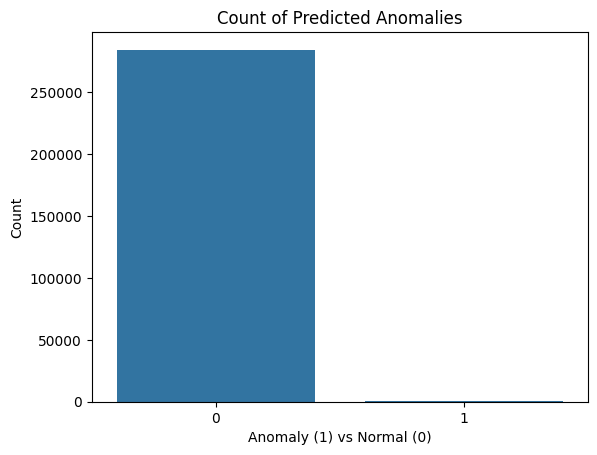

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add predictions to the original dataframe
df['predicted_anomaly'] = y_pred

# Count of predicted anomalies
sns.countplot(x='predicted_anomaly', data=df)
plt.title('Count of Predicted Anomalies')
plt.xlabel('Anomaly (1) vs Normal (0)')
plt.ylabel('Count')
plt.show()


### Chart 2: Visualize Transaction Dollar Amount by Prediction

**What you are looking at:** This chart compares the **dollar amount** of transactions the model classified as normal versus suspicious.

**What this tells us about fraud patterns:**
If the 'fraud flagged' box (1) shows significantly higher or more variable amounts than the 'normal' box (0), it suggests the model is partly using **transaction amount as a fraud signal** — which aligns with real-world fraud patterns (e.g., large unauthorized purchases).

**Business insight:** Understanding *which types* of transactions get flagged helps the fraud team prioritize reviews and helps product teams decide whether to add friction (e.g., SMS confirmation) at specific dollar thresholds.

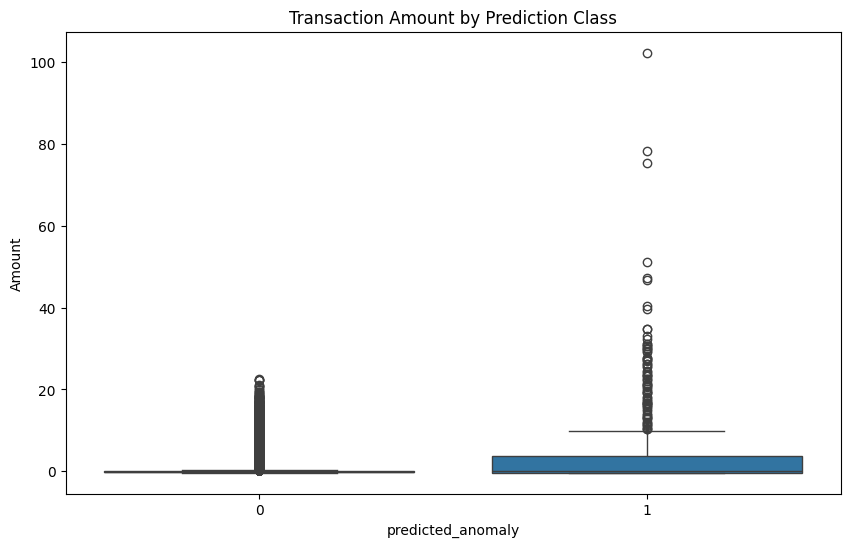

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()


### Chart 3: Feature Importance — What Is the Model Paying Attention To?

**What you are looking at:** This is a SHAP (SHapley Additive exPlanations) beeswarm plot. It is one of the most powerful tools we have for making AI decisions **transparent and explainable**.

Features at the **top of the chart** have the most influence on the model's decisions.

**Why Use SHAP?**  

- SHAP adds transparency to the model, even for complex algorithms like Isolation Forest.
- Helps **build trust**, especially in sensitive tasks like fraud detection.
- Guides feature selection and **future model improvements**.

**Why this matters for governance and compliance:**  

Financial services are subject to increasing regulatory pressure to explain automated decisions — especially those that affect customers (e.g., a blocked transaction). SHAP analysis helps us demonstrate *why* the model flagged a specific transaction, which is essential for:

- Responding to customer disputes  
- Satisfying regulatory audits (e.g., OSFI, FINTRAC in Canada)   
- Identifying and correcting potential bias in the model   


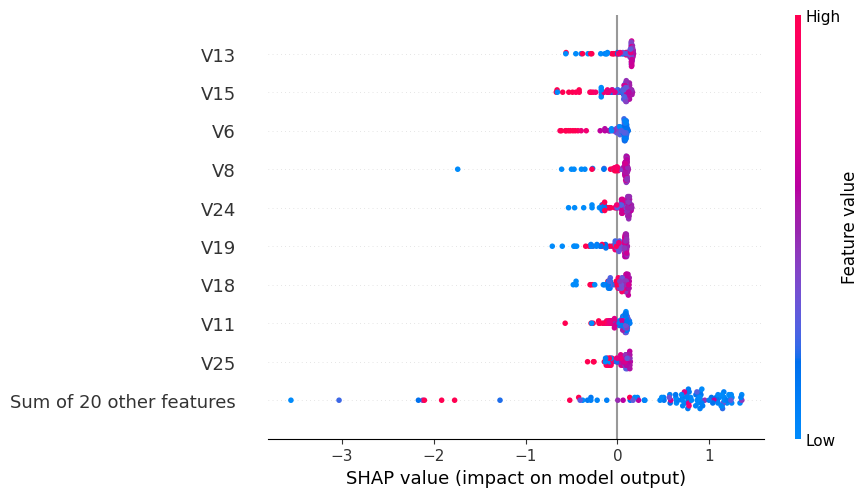

In [10]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:100])
shap.plots.beeswarm(shap_values)

---

## Business Impact Assessment

### 1. Cost-Benefit Analysis: False Postive vs. Missed Fraud

| Risk Type | Business Impact |
|---|---|
| **False Positives (legitimate transactions flagged as fraud)** | Customer frustration, increased call‑centre load, potential loss of trust, operational overhead. |
| **False Negatives (fraud not detected)** |Direct financial loss, regulatory exposure, reputational damage, downstream recovery costs.|

In financial services, **false negatives are typically more costly**, but excessive false positives can erode customer experience and brand trust. The model must strike a balance aligned with business priorities.


### 2. Recommendations for Model Improvement
Based on the notebook’s results, the following enhancements would meaningfully improve fraud detection:

- **Hybrid Model Approach**   
Combine anomaly detection with supervised learning using historical fraud labels.

- **Address class imbalance:**    
Apply oversampling techniques (e.g., SMOTE) to give the model more fraudulent examples to learn from.

- **Feature Engineering**    
Add behavioural features such as merchant category, velocity of transactions, device fingerprinting, and geolocation patterns.

- **Threshold Optimization**    
Adjust anomaly‑score thresholds to tune sensitivity based on business risk appetite.

- **Model Monitoring**     
Implement drift detection to ensure the model adapts to evolving fraud tactics.

- **Human‑in‑the‑Loop Review**    
Route borderline cases to analysts to reduce false positives.

### 3. Risk Assessment and Mitigation Strategies

| **Risk** | **Mitigation Strategy** |
|---|---|
| Model misses new fraud patterns | Continuous retraining and drift monitoring |
| Over‑flagging legitimate customers |Threshold tuning and human review workflows |
| Regulatory scrutiny | Full audit trail via Azure ML model registry |
| Data quality issues | Automated validation and anomaly checks before training |
| Operational outages | Deploy model redundantly across regions |

### 4. Stakeholder Communication Plan
To ensure transparency and alignment:
- **Executives**  receive quarterly summaries of fraud‑detection performance and cost savings.
- **Risk & Compliance**  receive documentation on model behaviour, limitations, and monitoring controls.
- **Customer Experience teams** receive guidance on handling false positives and customer messaging.
- **IT & Engineering** receive deployment and monitoring runbooks.

Clear communication ensures that all teams understand both the value and the limitations of the model.